<a href="https://colab.research.google.com/github/KesteHarshada87/Reinforcement_Learning/blob/main/Expt01(Bandit_Expt).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Running ε = 0.0
Running ε = 0.01
Running ε = 0.1


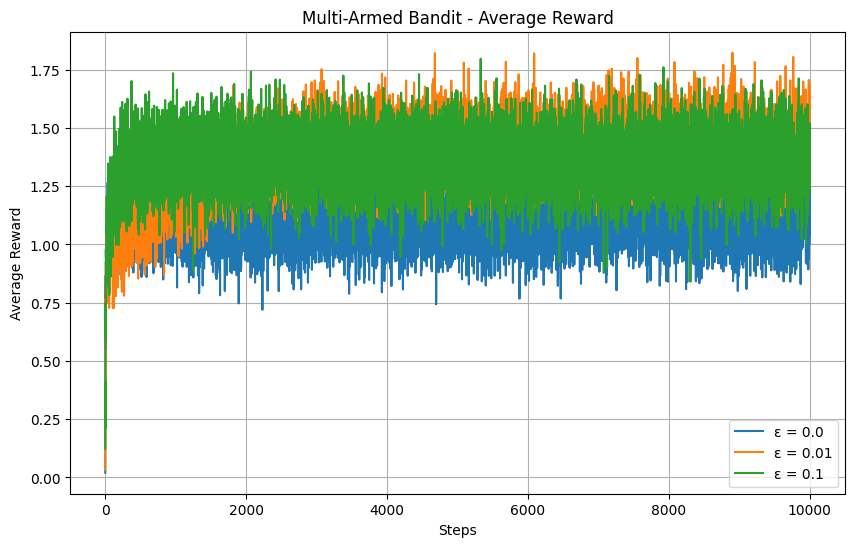

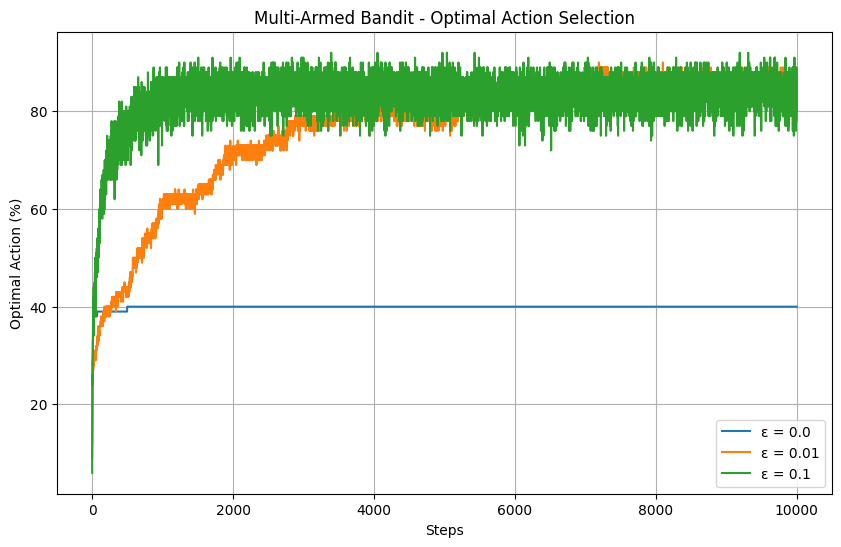


           FINAL RESULTS

Epsilon = 0.0
Average Reward = 1.185
Optimal Action = 40.00%

Epsilon = 0.01
Average Reward = 1.534
Optimal Action = 88.00%

Epsilon = 0.1
Average Reward = 1.307
Optimal Action = 78.00%


In [10]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# EXPERIMENT 1: MULTI-ARMED BANDIT PROBLEM
# Epsilon-Greedy Action Selection
# ============================================================

# Settings
NUM_ARMS = 10
NUM_STEPS = 10000
NUM_RUNS = 100

# Epsilon values
EPSILONS = [0.0, 0.01, 0.1]

# For reproducible results
np.random.seed(42)


# ============================================================
# ε-GREEDY ACTION SELECTION
# ============================================================

def choose_action(q_values, epsilon):

    # Exploration
    if np.random.rand() < epsilon:
        action = np.random.randint(NUM_ARMS)

    # Exploitation
    else:
        action = np.argmax(q_values)

    return action


# ============================================================
# MULTI-ARMED BANDIT EXPERIMENT
# ============================================================

def run_bandit(epsilon):

    # Store reward at every step
    rewards = np.zeros(NUM_STEPS)

    # Store whether optimal action was selected
    optimal_actions = np.zeros(NUM_STEPS)

    # Repeat experiment many times
    for run in range(NUM_RUNS):

        # True mean reward of each arm
        true_rewards = np.random.normal(0, 1, NUM_ARMS)

        # Estimated reward (Q-values)
        q_values = np.zeros(NUM_ARMS)

        # Number of times each arm was selected
        action_count = np.zeros(NUM_ARMS)

        # Find actual best arm
        best_arm = np.argmax(true_rewards)

        # Perform actions
        for step in range(NUM_STEPS):

            # Select action
            action = choose_action(q_values, epsilon)

            # Generate reward
            reward = np.random.normal(true_rewards[action], 1)

            # Increase action count
            action_count[action] += 1

            # Update Q-value
            q_values[action] = q_values[action] + (
                reward - q_values[action]
            ) / action_count[action]

            # Store reward
            rewards[step] += reward

            # Check optimal action
            if action == best_arm:
                optimal_actions[step] += 1

    # Average results over all runs
    rewards = rewards / NUM_RUNS

    optimal_actions = (optimal_actions / NUM_RUNS) * 100

    return rewards, optimal_actions


# ============================================================
# RUN ALL ε VALUES
# ============================================================

results_rewards = {}
results_optimal = {}

for epsilon in EPSILONS:

    print("Running ε =", epsilon)

    rewards, optimal = run_bandit(epsilon)

    results_rewards[epsilon] = rewards
    results_optimal[epsilon] = optimal


# ============================================================
# GRAPH 1: AVERAGE REWARD
# ============================================================

plt.figure(figsize=(10, 6))

for epsilon in EPSILONS:

    plt.plot(
        results_rewards[epsilon],
        label=f"ε = {epsilon}"
    )

plt.xlabel("Steps")
plt.ylabel("Average Reward")
plt.title("Multi-Armed Bandit - Average Reward")

plt.legend()
plt.grid(True)

plt.show()


# ============================================================
# GRAPH 2: OPTIMAL ACTION %
# ============================================================

plt.figure(figsize=(10, 6))

for epsilon in EPSILONS:

    plt.plot(
        results_optimal[epsilon],
        label=f"ε = {epsilon}"
    )

plt.xlabel("Steps")
plt.ylabel("Optimal Action (%)")
plt.title("Multi-Armed Bandit - Optimal Action Selection")

plt.legend()
plt.grid(True)

plt.show()


# ============================================================
# FINAL RESULTS
# ============================================================

print("\n======================================")
print("           FINAL RESULTS")
print("======================================")

for epsilon in EPSILONS:

    final_reward = results_rewards[epsilon][-1]
    final_optimal = results_optimal[epsilon][-1]

    print(f"\nEpsilon = {epsilon}")
    print(f"Average Reward = {final_reward:.3f}")
    print(f"Optimal Action = {final_optimal:.2f}%")